Found existing installation: mlflow 3.11.1
Uninstalling mlflow-3.11.1:
  Would remove:
    /Users/rishabh/Desktop/PatrollQ/.venv/bin/mlflow
    /Users/rishabh/Desktop/PatrollQ/.venv/lib/python3.12/site-packages/mlflow-3.11.1.dist-info/*
    /Users/rishabh/Desktop/PatrollQ/.venv/lib/python3.12/site-packages/mlflow/*
Proceed (Y/n)? ^C
Note: you may need to restart the kernel to use updated packages.


In [13]:
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("sqlite://///Users/rishabh/Desktop/PatrollQ/mlflow.db")


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [4]:
df=pd.read_csv('../data/cleaned_crime_records.csv')

In [5]:
df_sampled = df.sample(n=100000, random_state=42)

In [14]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = df_sampled[['Latitude','Longitude']]
X = X.astype('float32')



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mlflow.set_experiment("PatrollQ")
with mlflow.start_run(run_name="DBSCAN"):
    db = DBSCAN(eps=0.2, min_samples=150, algorithm='kd_tree', n_jobs=-1)
    df_sampled['cluster']=db.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, df_sampled['cluster'])
    mlflow.log_param("algorithm", "dbscan")
    mlflow.log_param("eps", 0.2)
    mlflow.log_param("min_samples", 150)
    mlflow.log_param("algorithm_inside",'kd_tree')
    mlflow.log_param("n_jobs", -1)
    mlflow.log_metric("silhouette_score", sil_score)


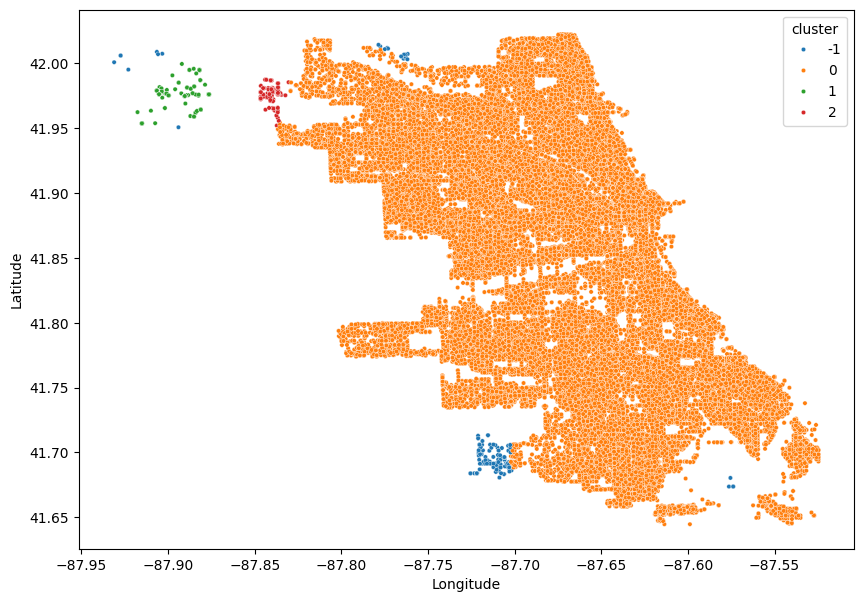

In [19]:
plt.figure(figsize=(10,7))
sns.scatterplot(
x=df_sampled['Longitude'],
y=df_sampled['Latitude'],
hue=df_sampled['cluster'],
palette='tab10',
s=10
)
plt.show()

In [21]:
df_sampled['cluster'].value_counts()

cluster
 0    99137
 1      502
 2      196
-1      165
Name: count, dtype: int64

In [22]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df_sampled['cluster'])
print(score)

0.1956770122051239


In [16]:
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import AgglomerativeClustering

# 1. This part CAN use n_jobs=-1!
# It creates a graph of which points are near each other.
connectivity = kneighbors_graph(X_scaled, n_neighbors=10, include_self=False, n_jobs=-1)

# 2. Pass that graph into the clustering model
mlflow.set_experiment("PatrollQ")
with mlflow.start_run(run_name='AgglomerativeClustering'):
    model = AgglomerativeClustering(n_clusters=8, connectivity=connectivity, linkage='ward')
    df_sampled['agg_cluster'] = model.fit_predict(X_scaled)
    sil_score=silhouette_score(X_scaled,df_sampled['agg_cluster'])
    mlflow.log_param("Algorithm", 'AgglometativeClustering')
    mlflow.log_param("linkage",'Ward')
    mlflow.log_param("n_clusters", 8)
    mlflow.log_metric("silhouette_score", sil_score)
print('Done')
    

/Users/rishabh/miniconda3/envs/ML_env/lib/python3.12/site-packages/sklearn/cluster/_agglomerative.py:323: UserWarning: the number of connected components of the connectivity matrix is 185 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


Done


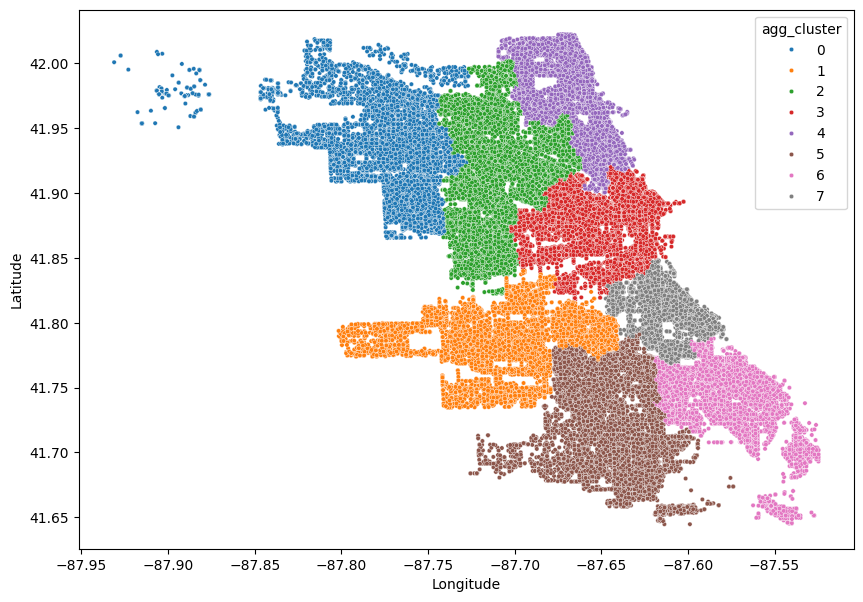

In [24]:
plt.figure(figsize=(10,7))
sns.scatterplot(
x=df_sampled['Longitude'],
y=df_sampled['Latitude'],
hue=df_sampled['agg_cluster'],
palette='tab10',
s=10
)
plt.show()

In [26]:
cluster_sizes = df_sampled['agg_cluster'].value_counts().reset_index()
cluster_sizes.columns = ['agg_cluster', 'size']

df_sampled = df_sampled.merge(cluster_sizes, on='agg_cluster')

In [27]:
df_sampled['agg_cluster'].value_counts()

agg_cluster
3    18712
2    16849
5    13996
0    11206
6    10728
1    10457
4    10323
7     7729
Name: count, dtype: int64

In [28]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df_sampled['agg_cluster'])
print(score)

0.34258174896240234
